In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import pytz

In [3]:
import pandas as pd  

# Load the dataset  
try:  
    data = pd.read_csv(r"C:\Users\user\Downloads\archive (3)\google_play_store_dataset.csv")  
except FileNotFoundError:  
    print("Error: The file 'google_play_store_dataset.csv' was not found.")  
    exit()  
except pd.errors.EmptyDataError:  
    print("Error: The file 'google_play_store_dataset.csv' is empty.")  
    exit()  
except Exception as e:  
    print(f"An unexpected error occurred: {e}")  
    exit()  

In [4]:
# Display dataset shape and column names
print("Dataset Shape:", data.shape)
print("Column Names:", data.columns.tolist())

Dataset Shape: (10841, 13)
Column Names: ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


In [5]:
# Display first and last 5 rows
print("\nFirst 5 Rows:\n", data.head())
print("\nLast 5 Rows:\n", data.tail())


First 5 Rows:
                                                  App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  Free     0       Everyone   
1     967   14M     500,000+  Free     0       Everyone   
2   87510  8.7M   5,000,000+  Free     0       Everyone   
3  215644   25M  50,000,000+  Free     0           Teen   
4     967  2.8M     100,000+  Free     0       Everyone   

                      Genres      Last Updated         Current Ver  \
0               Art & Design   January 7, 2018               1.0.0   
1  Art &

In [6]:
# Display data types and non-null counts
print("\nData Types & Non-Null Counts:\n")
print(data.info())


Data Types & Non-Null Counts:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB
None


In [7]:
# Display descriptive statistics
print("\nDescriptive Statistics:\n", data.describe(include='all'))


Descriptive Statistics:
            App Category       Rating Reviews                Size    Installs  \
count    10841    10841  9367.000000   10841               10841       10841   
unique    9660       34          NaN    6002                 462          22   
top     ROBLOX   FAMILY          NaN       0  Varies with device  1,000,000+   
freq         9     1972          NaN     596                1695        1579   
mean       NaN      NaN     4.193338     NaN                 NaN         NaN   
std        NaN      NaN     0.537431     NaN                 NaN         NaN   
min        NaN      NaN     1.000000     NaN                 NaN         NaN   
25%        NaN      NaN     4.000000     NaN                 NaN         NaN   
50%        NaN      NaN     4.300000     NaN                 NaN         NaN   
75%        NaN      NaN     4.500000     NaN                 NaN         NaN   
max        NaN      NaN    19.000000     NaN                 NaN         NaN   

         Type

In [8]:
# Display missing values per column
print("\nMissing Values (per column):\n", data.isnull().sum())


Missing Values (per column):
 App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


In [9]:
# Display unique categories and top 5 categories
print("\nUnique Categories:", data['Category'].nunique())
print("Top 5 Categories:\n", data['Category'].value_counts().head())


Unique Categories: 34
Top 5 Categories:
 Category
FAMILY      1972
GAME        1144
TOOLS        843
MEDICAL      463
BUSINESS     460
Name: count, dtype: int64


In [10]:
# Convert 'Reviews' and 'Rating' columns to numeric
data['Reviews'] = pd.to_numeric(data['Reviews'], errors='coerce')
data['Rating'] = pd.to_numeric(data['Rating'], errors='coerce')
# Remove rows with missing values in critical columns
data = data.dropna(subset=['Reviews', 'Rating', 'Category', 'App'])

In [11]:
# Filter apps containing 'C' in their names, with at least 10 reviews and ratings below 4.0
filtered_data = data[
    (data['App'].str.contains('C', case=False, na=False)) &
    (data['Reviews'] >= 10) &
    (data['Rating'] < 4.0)
]

# Include only categories with more than 50 apps
category_counts = filtered_data['Category'].value_counts()
valid_categories = category_counts[category_counts > 50].index
filtered_data = filtered_data[filtered_data['Category'].isin(valid_categories)]

In [12]:
# Define IST timezone
ist = pytz.timezone('Asia/Kolkata')
current_time = datetime.now(ist)

# Check if current time is between 10 AM and 12 PM IST
if 10 <= current_time.hour < 12:
    # Proceed to visualization
    pass
else:
    print("The graph is only available between 10 AM and 12 PM IST.")


The graph is only available between 10 AM and 12 PM IST.


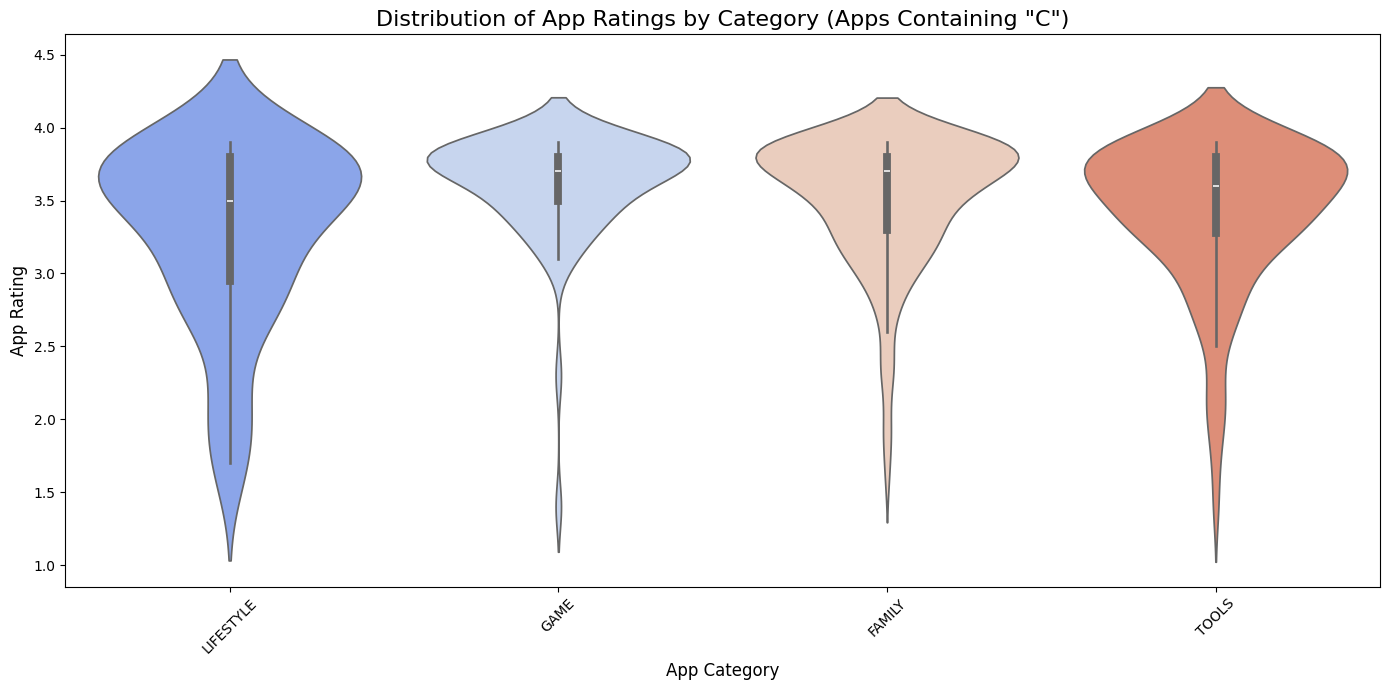

In [13]:
# Set up the figure for the violin plot
plt.figure(figsize=(14, 7))

# Create a violin plot to visualize the distribution of ratings by category
sns.violinplot(
    x='Category',
    y='Rating',
    data=filtered_data,
    palette='coolwarm',
    hue='Category',
    legend=False
)

# Customize the plot with titles and labels
plt.title('Distribution of App Ratings by Category (Apps Containing "C")', fontsize=16)
plt.xlabel('App Category', fontsize=12)
plt.ylabel('App Rating', fontsize=12)
plt.xticks(rotation=45, fontsize=10)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent clipping

# Display the plot
plt.show()